# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project
## Notebook P2-02: UBFC-rPPG Preprocessing

### What this notebook does

This notebook preprocesses the **UBFC-rPPG dataset** into a unified HDF5 format that is compatible with all other datasets in the QualityPhys pipeline.

Compared to ECG-Fitness (Notebook P2-01), UBFC-rPPG is the simpler dataset to preprocess - but is serves a critical role as the **clean baseline**: controlled conditions, no motion artefact, and a well-validated fingertip PPG reference. Results on UBFC establish the performance ceiling for the pipeline under ideal conditions, against which ECG-Fitness and other challanging datasets are compared.

Key characteristics of this dataset:
- Videos are standard uncompressed **8-bit RGB** - no colour space onversion needed beyond the standard `COLOR_BGR2RGB` swap that OpenCV requires
- Ground truth is **fingertip PPG** at ~60 Hz from a CMS50E pulse oximeter - must be resampled to 30 fps to align with video frames
- Subjects play a **time-sensitive maths game** - mildly elevated HR compared to resting, but no significant motion artefact or lighting variation
- Single activity per subject, single camera, stable indoor lighting - the most controlled dataset in the QualityPhys corpus

### Known dataset limitations

Per the dataset's terms of use, **facial images from subjects 21 and 27 must not be included in any publication, presentation, or report.** No raw video frames are stored in the HDF5 output - only extracted signal arrays - so this restriction is automatically satisfied by the pipeline.

UBFC-rPPG is a homogeneous, controlled dataset. Models trained exclusively on it generalise poorly to real-world conditions. It is used here as one component of a multi-dataset training corpus, not as a standalone training set.

### Dataset structure

```
└── subject1/ <-42 subjects (subject1 to subject49, some IDs missing)
├── vid.avi <- ~60 s face video, 30 fps, 640×480, uncompressed RGB
└── ground_truth.txt <- 3 rows (PPG waveform | HR | timestamps)
```

The ground truth file format - three rows, space-separated values on each row:
- Row 1: raw PPG waveform samples at ~60 Hz
- Row 2: instantaneous HR in BPM at ~60 Hz
- Row 3: timestamps in seconds (scientific notation)


### Pipeline

vid.avi (BGR decoded by OpenCV)
│
├─ 1. BGR → RGB conversion (standard, no YUV step needed)
├─ 2. MediaPipe Face Mesh -> ROI masks (forehead, cheeks)
└─ 3. Spatial mean RGB per ROI → [T, 3_ROIs, 3_ch]
│
└─ 4. Bandpass 0.7–3.5 Hz → POS → rPPG signal [T]
ground_truth.txt (row 1 = PPG waveform, ~60 Hz)
│
├─ 5. Resample from ~60 Hz → 30 fps using np.interp
├─ 6. PPG peak detection (NeuroKit2 nk.ppg_peaks)
└─ 7. Compute HR, RR intervals, RMSSD, SDNN, pNN50
8.  Signal Quality Index - rPPG SQI (no ECG SQI - PPG reference only)
9.  Discard recordings below quality threshold
10. Write continuous signals to HDF5

## 1. Environment Setup - Install required libraries


In [1]:
import subprocess, sys

packages = [
    "neurokit2", # ECG/PPG signal processing and peak detection
    "mediapipe", # Face mesh for ROI extraction
    "h5py", # HDF5 file reading and writing
    "opencv-python", # Video reading and YUV->RGB conversion
    "scipy", # Butterworth bandpass filter
    "numpy",
    "pandas",
    "matplotlib"
    ]

for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("All packeges installed")

All packeges installed


## 2. Imports and Configuration

**Key differences from ECG-Fitness configuration:**

* No `ECG_BP_LOW / ECG_BP_HIGH` - there is no ECG signal in UBFC
* No `ECG_SQI_THRESHOLD` - only rPPG quality can be assessed here
* No `MIN_Brightness` - UBFC recordings are stable indoor lighting, no low-light sessions exist in this dataset
* `PPG_FS` is new - the oximeter samples at ~60 Hz, video is at 30 fps, so the ground truth must be resampled before alignment
  

In [2]:
import os, warnings, cv2, h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from scipy.signal import butter, filtfilt

warnings.filterwarnings("ignore")

# Plot style
plt.rcParams.update({
    "figure.facecolor" : "#0f0f0f",
    "axes.facecolor" : "#1a1a2e",
    "axes.edgecolor" : "#444444",
    "axes.labelcolor" : "#e0e0e0",
    "xtick.color" : "#e0e0e0",
    "ytick.color" : "#e0e0e0",
    "text.color" : "#e0e0e0",
    "grid.color" : "#2a2a3e",
    "grid.linestyle" : "--",
    "grid.alpha" : 0.5,
    "figure.dpi" : 110,
})


# Paths

UBFC_DIR = "F:/UBFC"
OUTPUT_DIR = "E:/QualityPhys"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Dataset identity
DATASET_NAME = "ubfc_rppg"
HDF5_PATH = os.path.join(OUTPUT_DIR, "ubfc_rppg.h5")

# Signal processing parameters
FPS = 30.0 # UBFC video frame rate
PPG_FS = 60.0 # CMS50E oximeter sampling rate (Hz) 
# Ground truth is at ~60Hz - must be resampled to 30 fps to align with video frames before any label computation

# rPPG bandpass: 0.7-3.5 Hz = 42-210 BPM
# Lower bound 0.7 Hz removes: breathing drift, slow illumination changes
# Upper bound 3.5 Hz removes: motion noise, camera sensor noise
RPPG_BP_LOW = 0.7
RPPG_BP_HIGH = 3.5 


# PPG bandpass applied to the reference signal before peak detection
# Wider than rPPG to preserve waveform morphology
# 0.5 Hz removes vaseline wander, 8Hz preserves the systolic peak shape
PPG_BP_LOW = 0.5
PPG_BP_HIGH = 8.0



# Signal Quality Index threshold
# UBFC has only rPPG SQI - no ECG reference, no ECG SQI is computed
# Threshold is identical to ECG-Fitness for consistency across notebooks.
RPPG_SQI_THRESHOLD = 0.4 # autocorrelation-based quality score


# ROI landmark indices (MediaPipe Face Mesh, 468-point model)
FOREHEAD_LM = [10, 338, 297, 332, 284, 251, 389, 356, 454,
                  323, 361, 288, 397, 365, 379, 378, 400, 377,
                  152, 148, 176, 149, 150, 136, 172, 58, 132,
                  93, 234, 127, 162, 21, 54, 103, 67, 109]

LEFT_CHEEK_LM = [234, 227, 116, 123, 147, 213, 192, 214, 210,
                 211, 206, 203, 36, 101, 119, 229, 228]

RIGHT_CHEEK_LM = [454, 447, 345, 352, 376, 433, 416, 434, 430,
                  431, 426, 423, 266, 330, 348, 449, 448]

ROI_CONFIGS = {
    "forehead" : FOREHEAD_LM,
    "left_cheek" : LEFT_CHEEK_LM,
    "right_cheek" : RIGHT_CHEEK_LM
}



print("Configuration loaded.")
print(f"Dataset path : {UBFC_DIR}")
print(f"Output HDF5 : {HDF5_PATH}")
print(f"Output path : {OUTPUT_DIR}")
print(f"PPG ref rate : {PPG_FS} Hz (resampled -> {FPS} fps)")
print(f"rPPG bandpass: {RPPG_BP_LOW}-{RPPG_BP_HIGH} Hz ({RPPG_BP_LOW*60:.0f}-{RPPG_BP_HIGH*60:.0f} BPM)")
print(f"PPG bandpass : {PPG_BP_LOW}-{PPG_BP_HIGH} Hz")

Configuration loaded.
Dataset path : F:/UBFC
Output HDF5 : E:/QualityPhys\ubfc_rppg.h5
Output path : E:/QualityPhys
PPG ref rate : 60.0 Hz (resampled -> 30.0 fps)
rPPG bandpass: 0.7-3.5 Hz (42-210 BPM)
PPG bandpass : 0.5-8.0 Hz


## 3. Dataset Scan

UBFC-rPPG has a simple flat structure: one folder per subject, two files each. This scan builds an inventory so we know exactly what is available before processing begins - catching missing files early rather than during a long run.

Subject folder names are `subject1` through `subject49`, but not all IDs exist - only 42 subjects were released. The scan handles this automatically by iterating what is actually present rather than assuming a continuous range.

In [3]:
def scan_ubfc(root_dir: str) -> pd.DataFrame:
    """
    Walk the UBFC-rPPG directory and build a recording inventory.
    
    Returns a DataFrame with one row per subject, containing paths
    to both required files and a `complete` flag.
    """
    records = []

    for folder in sorted(os.listdir(root_dir)):
        folder_path = os.path.join(root_dir, folder)
        if not os.path.isdir(folder_path):
            continue

        # Subject folders are named subject1, subject2, etc.
        # Extract the integer ID for sorting and metadata
        if not folder.startswith("subject"):
            continue
        try:
            subject_id = int(folder.replace("subject", ""))
        except ValueError:
            continue

        video_path = os.path.join(folder_path, "vid.avi")
        gt_path = os.path.join(folder_path, "ground_truth.txt")

        has_video = os.path.exists(video_path)
        has_gt = os.path.exists(gt_path)

        records.append({
            "subject_id" : subject_id,
            "subject_folder" : folder,
            "video_path" : video_path if has_video else None,
            "gt_path" : gt_path if has_gt else None,
            "complete" : has_video and has_gt,
        })

    return pd.DataFrame(records).sort_values("subject_id").reset_index(drop=True)

df_inventory = scan_ubfc(UBFC_DIR)

complete = df_inventory["complete"].sum()
incomplete = (~df_inventory["complete"]).sum()

print(f"Subjects found: {len(df_inventory)}")
print(f"Complete : {complete}")
print(f"Incomplete : {incomplete}")
print()
print(df_inventory[["subject_id", "subject_folder", "complete"]].to_string(index=False))

Subjects found: 42
Complete : 42
Incomplete : 0

 subject_id subject_folder  complete
          1       subject1      True
          3       subject3      True
          4       subject4      True
          5       subject5      True
          8       subject8      True
          9       subject9      True
         10      subject10      True
         11      subject11      True
         12      subject12      True
         13      subject13      True
         14      subject14      True
         15      subject15      True
         16      subject16      True
         17      subject17      True
         18      subject18      True
         20      subject20      True
         22      subject22      True
         23      subject23      True
         24      subject24      True
         25      subject25      True
         26      subject26      True
         27      subject27      True
         30      subject30      True
         31      subject31      True
         32      subject32

## Load and Inspect Ground Truth (PPG)

### The ground_truth.txt format

Each subject has a single `ground_truth.txt` file with three rows:

| Row | Content | Rate|
|-----|---------|-----|
| 1 | Raw PPG waveform (blood volume pulse) | ~60 Hz |
| 2 | Instantaneous HR in BPM | ~60 Hz |
| 3 | Timestamps in seconds (scientific notation) | ~60 Hz |

### Why resampling is necessary

The oximeter records at approximately 60 Hz, but UBFC videps are at 30 fps.
To align the ground truth with video frames - so that frame k has the correct 
HR label - the PPG signal needs to be resampled from ~60 Hz down to 30 fps.
`np.interp` is being used for this: linear interpolation from the original timestamp grid onto a uniform 30 fps grid. This is the same approach used in Phase 1.

### What good PPG looks like

A clean fingertip PPG waveform has a clear repeating shape: a sharp systolic peak (arterial pressure rise) followed by a slower diastolic descent. If the signal looks flat or irregular, the recording has quality issues. 

Inspecting subject 1 (subject1)



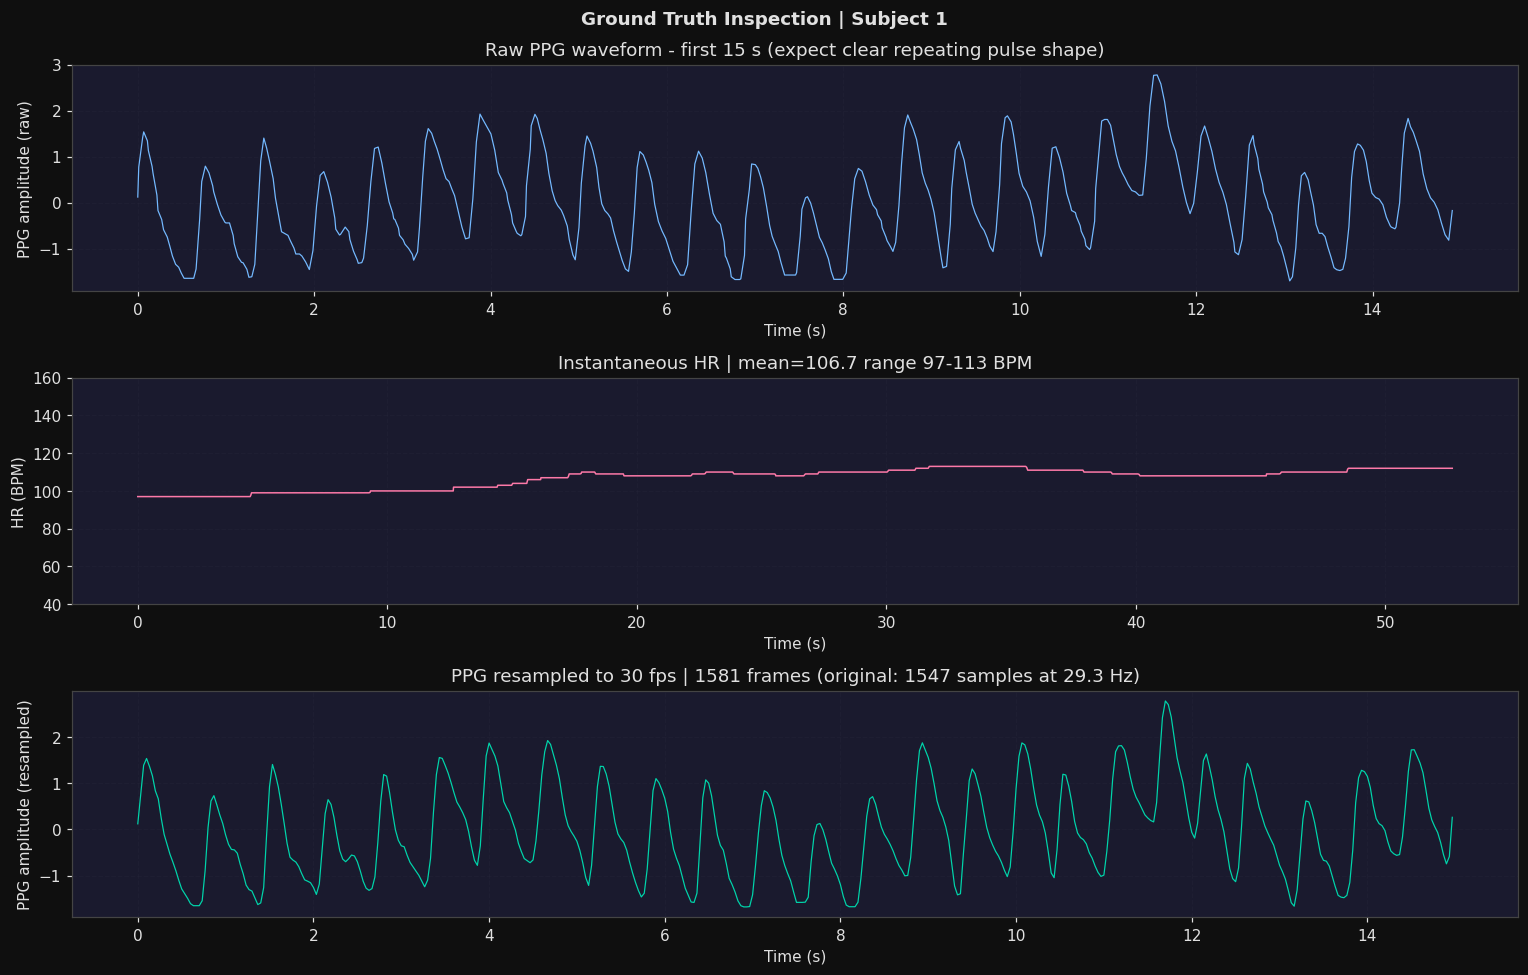

PPG sampling rate : 29.3 Hz
PPG duration : 52.7 s
Frames after resample: 1581
HR mean : 106.7 BPM range 97=113 BPM


In [4]:
def load_ground_truth(gt_path: str) -> dict:
    """
    Load UBFC-rPPG ground truth file.
    
    The file has no header - three rows of space-separated floats.
    Row indices: 0=PPG waveform, 1=HR, 2=timestamps.
    
    Return a dict with:
        ppg_raw : raw PPG waveform at original sampling rate
        hr_gt : instantaneous HR at original sampling rate
        timestamps : time axis in seconds
        ppg_fs : estimated sampling rate from timestamps
    """
    with open(gt_path, "r") as file:
        lines = file.readlines()

    ppg_raw = np.array(lines[0].split(), dtype=np.float32)
    hr_gt = np.array(lines[1].split(), dtype=np.float32)
    timestamps = np.array(lines[2].split(), dtype=np.float64)

    # Estimate actual sampling rate from timestamps
    ppg_fs = 1.0 / np.diff(timestamps).mean()

    return {
        "ppg_raw" : ppg_raw,
        "hr_gt" : hr_gt,
        "timestamps" : timestamps,
        "ppg_fs" : float(ppg_fs)
    }

def resample_to_fps(signal: np.ndarray, original_fs: float, target_fps: float) -> np.ndarray:
    """
    Resample a signal from its original sampling rate to video FPS.
    
    Uses linear interpolation (np.interp) on a uniform time grid.
    This is the correct approach for aligning physiological reference
    signals (PPG at ~60 Hz) with video frames (30 fps).
    
    The number of output samples equals the number of video frames,
    so signal[k] corresponds directly to frame k.
    """
    n_original = len(signal)
    n_target = int(n_original * target_fps / original_fs)

    original_times = np.linspace(0, 1, n_original)
    target_times = np.linspace(0, 1, n_target)

    return np.interp(target_times, original_times, signal).astype(np.float32)


def inspect_ground_truth(gt_path: str, subject_id: int) -> dict:
    """
    Load and visually inspect the ground truth for one subject.
    
    Plots:
        1. Raw PPG waveform - check for clear periodic pulse shape
        2. Instantaneous HR - check for physiologically plausible range
        3. Resample PPG at 30 fps - verify alignment is correct
    """
    gt = load_ground_truth(gt_path)
    ppg = gt["ppg_raw"]
    hr = gt["hr_gt"]
    ts = gt["timestamps"]
    fs = gt["ppg_fs"]

    # Resample to video FPS
    ppg_resampled = resample_to_fps(ppg, fs, FPS)

    fig, axes = plt.subplots(3, 1, figsize=(14,9))
    fig.suptitle(f"Ground Truth Inspection | Subject {subject_id}",
                fontsize=12, fontweight="bold")

    # Raw PPG - show first 15 seconds
    n_show = int(fs * 15)
    ax = axes[0]
    ax.plot(ts[:n_show], ppg[:n_show], color="#74b9ff", lw=0.8)
    ax.set_ylabel("PPG amplitude (raw)")
    ax.set_xlabel("Time (s)")
    ax.set_title("Raw PPG waveform - first 15 s (expect clear repeating pulse shape)")
    ax.grid(True, alpha=0.3)

    # Instantaneous HR
    ax = axes[1]
    valid_hr = hr[hr > 0]
    ax.plot(ts, hr, color="#fd79a8", lw=1.0)
    ax.set_ylabel("HR (BPM)")
    ax.set_xlabel("Time (s)")
    ax.set_title(f"Instantaneous HR | mean={valid_hr.mean():.1f} range {valid_hr.min():.0f}-{valid_hr.max():.0f} BPM")
    ax.set_ylim(40, 160)
    ax.grid(True, alpha=0.3)

    # Resample PPG 
    t_resampled = np.arange(len(ppg_resampled)) / FPS
    ax = axes[2]
    ax.plot(t_resampled[:int(FPS*15)], ppg_resampled[:int(FPS*15)],
           color="#00d4aa", lw=0.8)
    ax.set_ylabel("PPG amplitude (resampled)")
    ax.set_xlabel("Time (s)")
    ax.set_title(f"PPG resampled to {FPS:.0f} fps | {len(ppg_resampled)} frames (original: {len(ppg)} samples at {fs:.1f} Hz)")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/gt_inspect_s{subject_id:03d}.png",
               bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

    print(f"PPG sampling rate : {fs:.1f} Hz")
    print(f"PPG duration : {len(ppg)/fs:.1f} s")
    print(f"Frames after resample: {len(ppg_resampled)}")
    print(f"HR mean : {valid_hr.mean():.1f} BPM range {valid_hr.min():.0f}={valid_hr.max():.0f} BPM")

    return gt

# Inspect first complete subject
first_subject = df_inventory[df_inventory["complete"]].iloc[0]
print(f"Inspecting subject {first_subject.subject_id} ({first_subject.subject_folder})")
print()
gt_demo = inspect_ground_truth(first_subject["gt_path"], first_subject["subject_id"])

## 5. PPG Signal Processing - Peak Detection and HRV

### From PPG waveform to HR and HRV

The ground truth PPG waveform is a continous signal, not a list of HR values.
To compute RR intervals and HRV metrics invidual pulse peak must be detected in the PPG waveform - the same way ECG-Fitness uses R-peak detection on the ECG.

The pipeline is:
1. Bandpass filter the PPG (0.5-8Hz) to remove baseline wander and high-frequency noise
2. `nk.ppg_clean()` - NeuroKit2's additional PPG-specific cleaning
3. `nk.ppg_peaks()` - detect systolic peaks in the cleaned signal
4. Compute RR intervals from peak-to-peak timing
5. Derive HRV metrics from RR intervals

### Why PPG peaks are less precise than ECG R-peaks

The ECG R-wave is a sharp electrical event with timing precision of ~1 ms.
The PPG systolic peak is the mechanical consequence of cardiac contraction - it arrives 100-300 ms later (pulse transit time) and has a broader, rounder shape. This makes peak timing slightly less precise, which means HRV metrics derived from UBFC ground truth PPG are less accurate than those from ECG-Fitness. This is reflected in the metadata: `reference_type: PPG_finger` will carry lower confidence weight for HRV labels during training.



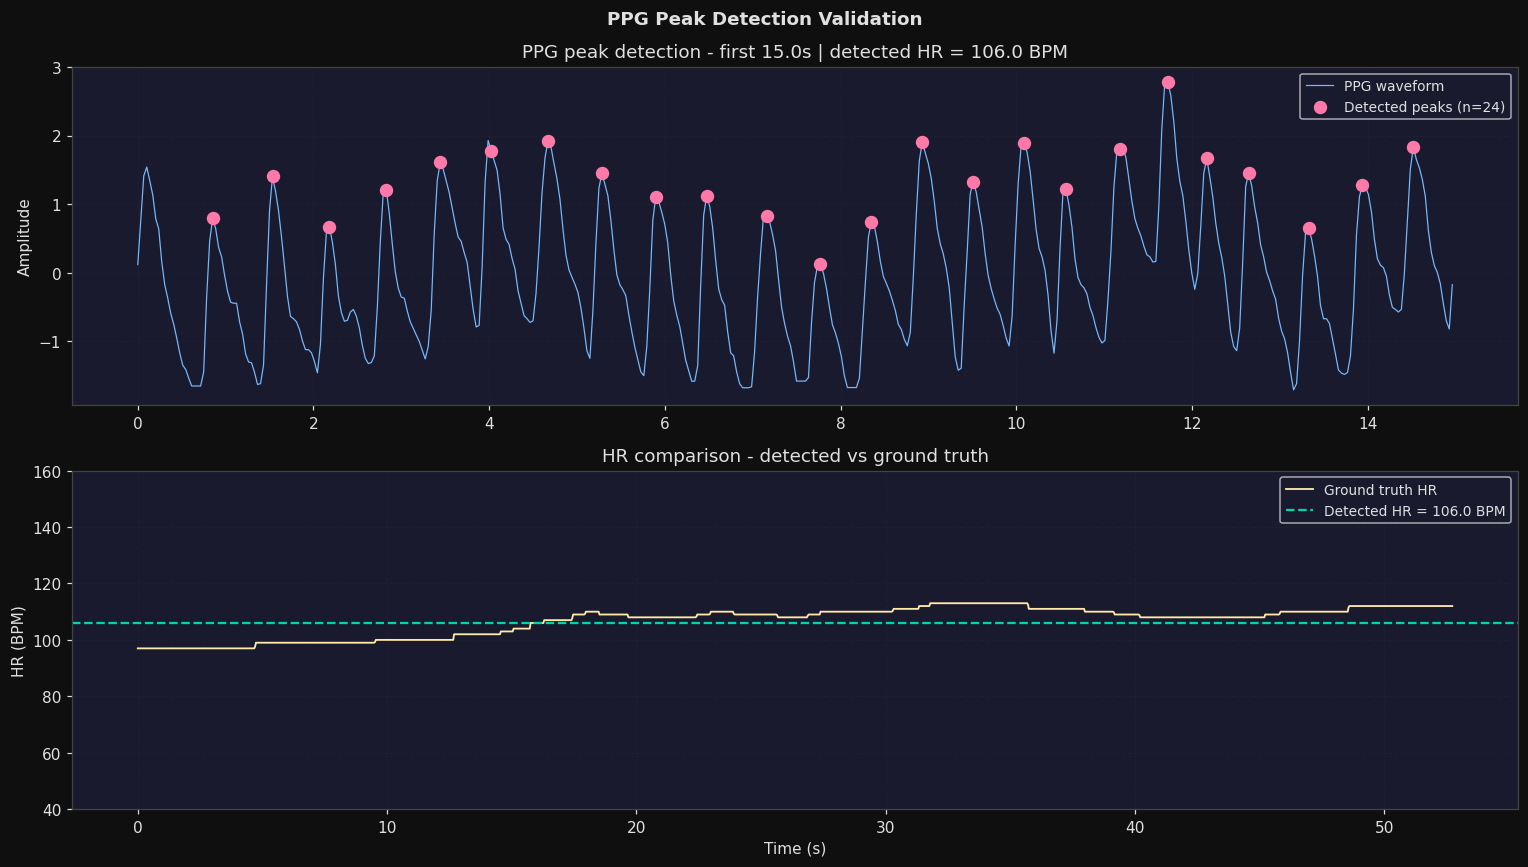

Detected HR : 106.0 BPM
Ground truth HR : 106.7 BPM
Difference : 0.8 BPM
Good agreement with ground truth HR (< 5 BPM)

HRV features:
RMSSD : 83.4 ms
SDNN : 59.7 ms
pNN50 : 55.6 %
HR mean : 105.953157 BPM


In [5]:
def bandpass_filter(signal: np.ndarray, fs: float, low: float, high: float, order: int = 2) -> np.ndarray:
    """
    Zero-phase Butterworth bandpass filter.
    
    Zero-phase (filtfilt) preserves peak timing - critical for accurate 
    RR interval computation. Shared function across all QualityPhys notebooks.

    Args:
        signal : 1D array
        fs : sampling frequency in Hz
        low : lower cutoff in Hz
        high : upper cutoff in Hz
        order : filter order (2 = gentle, avoids ringing artefacts)
    """
    nyq = fs / 2.0
    b,a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, signal).astype(np.float32)


def detect_ppg_peaks(ppg_raw: np.ndarray, ppg_fs:float) -> tuple:
    """
    Detect systolic peaks in a PPG waveform using NeuroKit2.
    
    Mirros the ECG R-peak detection pattern from ECG-Fitness notebook:
        clean -> detect -> compute RR intervals -> compute HR
        
    The key difference from ECG: nk.ppg_clean() and nk.ppg_peaks()
    instead of nk.ecg_clean() and nk.ecg_peaks(). The downstream computation
    of RR intervals and HRC is identical.
    
    Returns:
        peak_indices : sample indices of detected systolic peaks
        rr_ms : RR intervals in milliseconds
        hr_mean : mean HR in BPM
    """
    # Filter to remove baseline wander and high-frequency noise
    ppg_filtered = bandpass_filter(ppg_raw, ppg_fs, PPG_BP_LOW, PPG_BP_HIGH)

    # NeuroKit2 PPG-specific cleaning (additional standardisation)
    ppg_clean = nk.ppg_clean(ppg_filtered, sampling_rate=int(ppg_fs))

    # Detect systolic peaks
    peaks_dict, _ = nk.ppg_peaks(ppg_clean, sampling_rate=int(ppg_fs))
    peak_indices = np.where(peaks_dict["PPG_Peaks"] == 1)[0]

    if len(peak_indices) < 3:
        return peak_indices, np.array([]), float("nan")

    ## RR intervals in milliseconds
    rr_ms = np.diff(peak_indices) / ppg_fs * 1000.0
    hr_mean = float(60000.0 / rr_ms.mean())

    return peak_indices, rr_ms, hr_mean 

def compute_hrv_features(rr_ms: np.ndarray) -> dict:
    """
    Compute time-domain HRV features from RR intervals.
    
    Identical implementation to ECG-Fitness notebook - same metrics,
    same physiological filters, same NaN handling. The unified output 
    contract requires consistent HRV keys across all datasets.
    
    Clinical note: 30-second windows give ~30-40 beats - sufficient for 
    RMSSD and pNN50, but no for frequency-domain LF/HF (needs 5+ min).
    Only time-domain features are computed here.
    """
    nan_result = {
        "mean_rr_ms" : float("nan"),
        "sdnn_ms" : float("nan"),
        "rmssd_ms" : float("nan"),
        "pnn50_pct" : float("nan"),
        "hr_mean_bpm" : float("nan"),
        "hr_min_bpm" : float("nan"),
        "hr_max_bpm" : float("nan")
    }

    if len(rr_ms) < 3:
        return nan_result

    # Remove physiologically impossible RR intervals
    # < 300 ms = HR > 200 BPM | > 2000 ms = HR < 30 BPM
    rr_clean = rr_ms[(rr_ms > 300) & (rr_ms < 2000)]

    if len(rr_clean) < 3:
        return nan_result

    successive_diffs = np.diff(rr_clean)

    result = {
        "mean_rr_ms" : float(rr_clean.mean()),
        "sdnn_ms" : float(rr_clean.std()),
        "rmssd_ms" : float(np.sqrt(np.mean(successive_diffs ** 2))),
        "pnn50_pct" : float((np.abs(successive_diffs) > 50).mean() * 100),
        "hr_mean_bpm" : float(60000.0 / rr_clean.mean()),
        "hr_min_bpm" : float(60000.0 / rr_clean.max()), # min HR = max RR
        "hr_max_bpm" : float(60000.0 / rr_clean.min()) # max HR = min RR
    }
    return result


def validate_ppg_peaks(ppg_raw: np.ndarray, peak_indices: np.ndarray, hr_detected: float,
                      hr_gt: np.ndarray, ppg_fs: float, window_sec: float = 15.0) -> dict:
    """
    Visual validation of PPG peak detection.
    
    Mirrors validate_r_peaks from ECG-Fitness notebook:
    plots detected peaks overlaid on the waveform, and compares
    Computed HR agains the provided ground truth HR.
    
    What correct detection looks like:
        - One marker at the top of each systolic peak
        - No double-detections (two markers on one pulse)
        - No missed peaks (pulse with no marker)
        - HR within ±5 BPM of the ground truth HR
    """
    n_show = int(window_sec * ppg_fs)
    t = np.arange(n_show) / ppg_fs
    peaks_in_window = peak_indices[peak_indices < n_show]

    fig, axes = plt.subplots(2, 1, figsize=(14,8))
    fig.suptitle("PPG Peak Detection Validation", fontsize=12, fontweight="bold")

    # PPG with detected peaks
    ax = axes[0]
    ax.plot(t, ppg_raw[:n_show], color="#74b9ff", lw=0.8, label="PPG waveform")
    if len(peaks_in_window) > 0:
        ax.scatter(peaks_in_window / ppg_fs, ppg_raw[peaks_in_window],
                  color="#fd79a8", s=60, zorder=5, label=f"Detected peaks (n={len(peaks_in_window)})")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"PPG peak detection - first {window_sec}s | detected HR = {hr_detected:.1f} BPM")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # HR comparison
    ax = axes[1]
    valid_gt_hr = hr_gt[hr_gt > 0]
    t_gt = np.linspace(0, len(ppg_raw) / ppg_fs, len(valid_gt_hr))
    ax.plot(t_gt, valid_gt_hr, color="#ffeaa7", lw=1.2, label="Ground truth HR")
    ax.axhline(hr_detected, color="#00d4aa", lw=1.5, ls="--",
              label=f"Detected HR = {hr_detected:.1f} BPM")
    ax.set_ylabel("HR (BPM)")
    ax.set_xlabel("Time (s)")
    ax.set_title("HR comparison - detected vs ground truth")
    ax.set_ylim(40, 160)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/ppg_peaks_validation.png", bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

    gt_hr_mean = float(valid_gt_hr.mean())
    hr_diff = abs(hr_detected - gt_hr_mean)

    print(f"Detected HR : {hr_detected:.1f} BPM")
    print(f"Ground truth HR : {gt_hr_mean:.1f} BPM")
    print(f"Difference : {hr_diff:.1f} BPM")

    if hr_diff < 5:
        print("Good agreement with ground truth HR (< 5 BPM)")
    elif hr_diff < 10:
        print("Moderate discrepency - check signal visually")
    else:
        print("Large discrepancy - possible peak detection failure")

    return {
        "hr_detected" : hr_detected,
        "hr_gt_mean" :  gt_hr_mean,
        "hr_diff" : hr_diff,
        "n_peaks" : len(peak_indices)
    }

# Run on first subject
ppg_raw_demo = gt_demo["ppg_raw"]
ppg_fs_demo = gt_demo["ppg_fs"]

peak_indices_demo, rr_ms_demo, hr_mean_demo = detect_ppg_peaks(
    ppg_raw_demo, ppg_fs_demo)

validation_result = validate_ppg_peaks(
    ppg_raw_demo, peak_indices_demo, hr_mean_demo,
    gt_demo["hr_gt"], ppg_fs_demo)

hrv_demo = compute_hrv_features(rr_ms_demo)
print()
print("HRV features:")
print(f"RMSSD : {hrv_demo['rmssd_ms']:.1f} ms")
print(f"SDNN : {hrv_demo['sdnn_ms']:.1f} ms")
print(f"pNN50 : {hrv_demo['pnn50_pct']:.1f} %")
print(f"HR mean : {hrv_demo['hr_mean_bpm']:1f} BPM")

## 6. Signal Quality Index (SQI)

UBFC-rPPG uses only one SQI score per recording - the **rPPG SQI** - because there is no ECG signal to assess. The ECG SQI from the ECG-Fitness notebook is simply not applicable here.

The rPPG SQI is identical to the ECG-Fitness implementation: normalised autocorrelation of the extracted POS signal at the expected heartbeat lag. A clean rPPG signal is periodic at the heart rate, so a strong autocorrelation at that lag indicates good signal quality.

UBFC recordings are well-controlled indoor conditions - higher consistency rPPG values are expected here than in ECG-Fitness, where motion artefact from exercise degrades the optical signal. If a UBFC recording fails the SQI threshold (0.4), it is a genuine quality problem - face tracking failure, camera shake, or corrupted file - no a conditions issue.

In [6]:
def compute_rppg_sqi(rppg_signal: np.ndarray, hr_bpm: float, fs: float = FPS) -> float:
    """
    rPPG Signal Quality Index - autocorrelation at expected HR lag.
    
    Identical implementation to ECG-Fitness notebook.
    A score near 1.0 means the rPPG signal has a strong periodic component
    at the expected hearbeat frequency. Near 0 means no clear periodicity.
    
    Args:
        rppg_signal : POS-extracted signal, bandpass filtered and z-scored
        hr_bpm : expected HR in BPM (from PPG ground truth)
        fs : video sampling rate in fps
        
    """
    if hr_bpm <= 0 or np.isnan(hr_bpm):
        return float("nan")

    beat_period_samples = int(round(fs * 60.0 / hr_bpm))

    if beat_period_samples >= len(rppg_signal):
        return float("nan")

    s = rppg_signal - rppg_signal.mean()
    autocorr_zero = np.dot(s, s)
    if autocorr_zero < 1e-10:
        return 0.0

    autocorr_lag = np.dot(s[:-beat_period_samples], s[beat_period_samples:])
    sqi = float(autocorr_lag / autocorr_zero)
    return float(max(0.0, min(sqi, 1.0)))

print("rPPG SQI function defined.")
print(f"Threshold : {RPPG_SQI_THRESHOLD} (recordings below this are discarded)")
    

rPPG SQI function defined.
Threshold : 0.4 (recordings below this are discarded)


## 7. rPPG Extraction (Video -> Signal)

The rPPG pipeline is identical across all QualityPhys notebooks: MediaPipe Face Mesh -> ROI polygon masks -> spatial mean RGB -> bandpass filter -> POS method -> z-score normalisation.

The only difference from ECG-Fitness is the absence of a YUV conversion step. UBFC videos are stored as standard uncompressed RGB, so OpenCV decodes them directly to BGR - the standard `COLOR_BGR2RGB` swap is all that is needed.



In [7]:
# Download MediaPipe face landmarker model if not present
MODEL_PATH =  "./face_landmarker.task"
if not os.path.exists(MODEL_PATH):
    print("Downloading MediaPipe face landmarker model...")
    url = ("https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task")
    urllib.request.urlretrieve(url, MODEL_PATH)
    print("Downloaded.")
else:
    print("Face landmarker model already present.")


def get_roi_mask(landmarks, frame_shape: tuple, landmark_indices: list) -> np.ndarray:
    """
    Build binary polygon mask for one ROI from landmark indices.
    """
    h, w  = frame_shape[:2]
    pts = np.array([[int(landmarks[idx].x *w), int(landmarks[idx].y * h)] for idx in landmark_indices],
                  dtype=np.int32)
    mask = np.zeros((h,w), dtype=np.uint8)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def extract_roi_signals(video_path: str, roi_configs: dict, max_frames: int = None) -> dict:
    """
    Extract spatially-averaged RGB time series from facial ROIs.
    
    UBFC-specific: no YUV conversion - video is already BGR.
    OpenCV decodes it directly, only COLOR_BGR2RGB to swap channel order for MediaPipe
    (which expects RGB) is needed.
    
    This is simpler than the ECG-Fitness version precisely because UBFC stores
    standard uncompressed 8-bit RGB video.
    """
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    roi_sigs = {name: [] for name in roi_configs}
    n_frames = 0
    no_face_ct = 0

    base_options = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
    options = mp_vision.FaceLandmarkerOptions(
        base_options=base_options,
        running_mode=mp_vision.RunningMode.VIDEO,
        num_faces=1,
    )

    with mp_vision.FaceLandmarker.create_from_options(options) as landmarker:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            if max_frames and n_frames >= max_frames:
                break

            # Standard BGR -> RGB swap - no YUV step needed for UBFC
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
            ts_ms = int((n_frames / fps) * 1000)
            result = landmarker.detect_for_video(mp_image, ts_ms)

            if result.face_landmarks:
                lm = result.face_landmarks[0]
                for name, indices in roi_configs.items():
                    mask = get_roi_mask(lm, rgb_frame.shape, indices)
                    if mask.sum() > 0:
                        r = rgb_frame[:, :, 0][mask == 1].mean()
                        g = rgb_frame[:, :, 1][mask == 1].mean()
                        b = rgb_frame[:, :, 2][mask == 1].mean()
                        roi_sigs[name].append(np.array([r, g, b], dtype=np.float32))
                    else:
                        fallback = roi_sigs[name][-1] if roi_sigs[name] else np.zeros(3, np.float32)
                        roi_sigs[name].append(fallback)

            else:
                no_face_ct += 1
                for name in roi_configs:
                    fallback = roi_sigs[name][-1] if roi_sigs[name] else np.zeros(3, np.float32)
                    roi_sigs[name].append(fallback)

            n_frames += 1

    cap.release()

    result_dict = {name: np.array(vals) for name, vals in roi_sigs.items()}
    result_dict["__fps__"] = fps
    result_dict["__n_frames__"] = n_frames
    result_dict["__no_face_pct__"] = round(100 * no_face_ct / max(n_frames, 1), 1)
    return result_dict

def extract_pos(clip_roi: dict) -> np.ndarray:
    """
    POS method averaged across all ROIs.
    Identical implementation across all QualityPhys notebooks
    """
    P = np.array([[0, 1, -1], [-2, 1,1]], dtype=np.float64)
    roi_names = [k for k in clip_roi if not k.startswith("__")]
    signals = []

    for name in roi_names:
        C = clip_roi[name].astype(np.float64)
        Cn = C / (C.mean(axis=0) + 1e-8)
        S = P @ Cn.T
        h = S[0] + (S[0].std() / (S[1].std() + 1e-8)) * S[1]
        signals.append(h)

    combined = np.mean(signals, axis=0)
    filtered = bandpass_filter(combined, FPS, RPPG_BP_LOW, RPPG_BP_HIGH)

    # Per-clip z-score normalisation - removes DC offset differences
    # between subjects without affecting the temporal rhythm
    mu, sigma = filtered.mean(), filtered.std() + 1e-8
    return ((filtered - mu) / sigma).astype(np.float32)

print("rPPG extraction functions defined.")

Face landmarker model already present.
rPPG extraction functions defined.


## 8. Full Pipeline - Single Subject

Run the complete pipeline on one subject and verify every output before processing the full dataset.

The output dictionary matches the unified QualityPhys output contract exacltly - the same keys and shapes as ECG-Fitness, with `reference_type`: `PPG_finger` instead of `ECG`, and no ECG-specific fields. 

In [8]:
def process_single_subject(video_path: str, gt_path: str, subject_id: int, max_frames: int = None) -> tuple:
    """
    Run the full preprocessing pipeline on one UBFC-rPPG subject.
    
    Returns a tuple of (result_dict, reason_string).
    result_dict is None if the subject was skipped for any reason.
    reson_string is 'ok' on success or describes the skip reason.
    
    Key differences from ECG-Fitness process_single_recording:
        - No brightness pre-screen (UBFC is always well-lit)
        - No ECG loading, filtering, or R-peak detection
        - Ground truth comes from ground_truth.txt, not viatom-raw.csv
        - Sync is done by resampling (np.interp), not index lookup
        - No ECG SQI - only rPPG SQI is computed
    """
    # Step 1: Load ground truth PPG
    gt = load_ground_truth(gt_path)
    ppg = gt["ppg_raw"]
    hr_gt = gt["hr_gt"]
    ppg_fs = gt["ppg_fs"]

    # Flat signal check - zero variance means corrupted file
    if ppg.max() - ppg.min() < 1e-6:
        print(f"SKIP subject {subject_id}: flat PPG signal (corrupted file?)")
        return None, "flat_ppg_signal"

    # Step 2: Detect PPG peaks + compute HR and HRV
    peak_indices, rr_ms, hr_mean = detect_ppg_peaks(ppg, ppg_fs)

    if np.isnan(hr_mean) or hr_mean < 40 or hr_mean > 180:
        print(f"SKIP subject {subject_id}: implausible HR ({hr_mean:.1f} BPM)")
        return None, f"implausible_hr ({hr_mean:.1f} BPM)"

    hrv = compute_hrv_features(rr_ms)

    # Step 3: Resample PPG and HR ground truth to video FPS
    ppg_resampled = resample_to_fps(ppg, ppg_fs, FPS)
    hr_resampled = resample_to_fps(hr_gt, ppg_fs, FPS)

    # Step 4: Extract rPPG signal from video
    roi_data = extract_roi_signals(video_path, ROI_CONFIGS, max_frames=max_frames)
    n_frames = roi_data["__n_frames__"]
    no_face = roi_data["__no_face_pct__"]

    if no_face > 20.0:
        print(f"SKIP subject {subject_id}: to many frames without face ({no_face:.1f})")
        return None, f"no_face ({no_face:.1f}%)"

    rppg_signal = extract_pos(roi_data)

    # Stack ROI RGB: [T, 3_ROIs, 3_ch]
    roi_names = [k for k in roi_data if not k.startswith("__")]
    roi_rgb = np.stack([roi_data[name] for name in roi_names], axis=1).astype(np.float32)

    # Step 5: rPPG SQI
    rppg_sqi = compute_rppg_sqi(rppg_signal, hr_mean, FPS)
    if rppg_sqi < RPPG_SQI_THRESHOLD:
        print(f"SKIP subject {subject_id}: rPPG SQI too low ({rppg_sqi:.3f})")
        return None, f"rppg_sqi_low ({rppg_sqi:.3f})"

    # Step 6: Align all signals to shortes common length
    T = min(len(rppg_signal), len(ppg_resampled), len(hr_resampled), roi_rgb.shape[0])
    rppg_signal = rppg_signal[:T]
    ppg_resampled = ppg_resampled[:T]
    hr_continuous = hr_resampled[:T]
    roi_rgb = roi_rgb[:T]

    print(f"Subject {subject_id:03d} frames={T} HR={hr_mean:.1f} rPPG_SQI={rppg_sqi:.2f} no_face={no_face:.1f})%")

    result = {
        # Signal 
        "rppg_signal" : rppg_signal, # [T] float32
        "roi_rgb" : roi_rgb,# [T, 3, 3] float 32
        "reference_signal" : ppg_resampled, # [T] float 32 (PPG at FPS)
        "hr_continuous" : hr_continuous, # [T] float32
        "rr_intervals" : rr_ms.astype(np.float32), # [N_beats]

        # Scalar HRV labels
        "hr_mean" : float(hr_mean),
        "rmssd_ms" : hrv["rmssd_ms"],
        "sdnn_ms" : hrv["sdnn_ms"],
        "pnn50_pct" : hrv["pnn50_pct"],

        # Metadata
        "subject_id" : subject_id,
        "activity_id" : "01", # UBF has one activity per subject
        "activity_name" : "maths_game",
        "dataset" : DATASET_NAME,
        "reference_type" : "PPG_finger", # lower HRV confidence than ECG
        "n_frames" : T,
        "fps" : FPS,
        "rppg_sqi" : float(rppg_sqi),
        "no_face_pct" : float(no_face),
    }
    return result, "ok"

# Test on first subject
print("Running single-subject pipeline test (first 300 frames)...")
demo_result, demo_reason = process_single_subject(
    first_subject["video_path"],
    first_subject["gt_path"],
    first_subject["subject_id"],
    max_frames=300,
)

if demo_result is not None:
    print()
    print("Output shapes:")
    for key, value in demo_result.items():
        if hasattr(value, "shape"):
            print(f"{key:<20} : {value.shape}")
        elif isinstance(value, float):
            print(f"{key:<20} : {value:.3f}")
        else:
            print(f"{key:<20} : {value}")
    else:
        print(f"Demo subject skipped - reason: {demo_reason}")

Running single-subject pipeline test (first 300 frames)...
Subject 001 frames=300 HR=106.0 rPPG_SQI=0.74 no_face=0.0)%

Output shapes:
rppg_signal          : (300,)
roi_rgb              : (300, 3, 3)
reference_signal     : (300,)
hr_continuous        : (300,)
rr_intervals         : (91,)
hr_mean              : 105.953
rmssd_ms             : 83.407
sdnn_ms              : 59.735
pnn50_pct            : 55.556
subject_id           : ()
activity_id          : 01
activity_name        : maths_game
dataset              : ubfc_rppg
reference_type       : PPG_finger
n_frames             : 300
fps                  : 30.000
rppg_sqi             : 0.738
no_face_pct          : 0.000
Demo subject skipped - reason: ok


## 9. Write to HDF5

The HDF5 schema is identical to the ECG-Fitness notebook. The same `write_recording_to_hdf5` and `initialise_hdf5` functions work unchanged because the result dictionary uses the same keys.

In [9]:
def write_recording_to_hdf5(h5_file: h5py.File, result: dict) -> None:
    """
    Write one preprocessed recroding to the HDF5 file.
    
    Identical implementation to ECG-Fitness notebook.
    The unified output contract means this function works for any dataset.
    Resume-safe: skips groups that already exist.
    """
    subj = f"{result['subject_id']:03d}"
    act = result["activity_id"]
    path = f"subjects/{subj}/recordings/{act}"

    if path in h5_file:
        print(f"Already exists: {path} - skipping")
        return

    grp = h5_file.require_group(path)

    grp.create_dataset("rppg_signal", data=result["rppg_signal"],
                      compression="gzip", compression_opts=4)
    grp.create_dataset("roi_rgb", data=result["roi_rgb"],
                      compression="gzip", compression_opts=4)
    grp.create_dataset("reference_signal", data=result["reference_signal"],
                      compression="gzip", compression_opts=4)
    grp.create_dataset("hr_continuous", data=result["hr_continuous"],
                      compression="gzip", compression_opts=4)
    grp.create_dataset("rr_intervals", data=result["rr_intervals"],
                      compression="gzip", compression_opts=4)
    attrs = {
        "subject_id" : result["subject_id"],
        "activity_id" : result["activity_id"],
        "activity_name" : result["activity_name"],
        "dataset" : result["dataset"],
        "reference_type" : result["reference_type"],
        "n_frames" : result["n_frames"],
        "fps" : result["fps"],
        "hr_mean" : result["hr_mean"],
        "rmssd_ms" : result["rmssd_ms"] if not np.isnan(result["rmssd_ms"]) else -1.0,
        "sdnn_ms" : result["sdnn_ms"] if not np.isnan(result["sdnn_ms"]) else -1.0,
        "pnn50_pct" : result["pnn50_pct"] if not np.isnan(result["pnn50_pct"]) else -1.0,
        "rppg_sqi" : result["rppg_sqi"],
        "no_face_pct" : result["no_face_pct"],
    }
    for key, value in attrs.items():
        grp.attrs[key] = value 

def initialise_hdf5(output_path: str) -> h5py.File:
    """
    Create or open the HDF5 file with top-level metadata.
    Mode 'a' = append - safe to reopen without losing existing data.
    """
    h5 = h5py.File(output_path, "a")

    if "metadata" not in h5:
        meta = h5.require_group("metadata")
        meta.attrs["dataset_name"] = DATASET_NAME
        meta.attrs["preprocessing_version"] = "1.0"
        meta.attrs["fps"] = FPS
        meta.attrs["ppg_fs_original"] = PPG_FS
        meta.attrs["rppg_bp_low"] = RPPG_BP_LOW
        meta.attrs["rppg_bp_high"] = RPPG_BP_HIGH
        meta.attrs["ppg_bp_low"] = PPG_BP_LOW
        meta.attrs["ppg_bp_high"] = PPG_BP_HIGH
        meta.attrs["rppg_sqi_threshold"] = RPPG_SQI_THRESHOLD
    
    return h5


# Write demo result
print(f"Writing to : {HDF5_PATH}")
if demo_result is not None:
    with initialise_hdf5(HDF5_PATH) as h5:
        write_recording_to_hdf5(h5, demo_result)
    print("Demo subject written successfully")

    # Readback verification
    with h5py.File(HDF5_PATH, "r") as h5:
        subj = f"{demo_result['subject_id']:03d}"
        act = demo_result["activity_id"]
        grp = h5[f"subjects/{subj}/recordings/{act}"]
        print()
        print("Readback verification:")
        for ds_name in grp.keys():
            print(f"{ds_name:<20}: {grp[ds_name].shape}")
        print("Attributes:")
        for key, value in grp.attrs.items():
            print(f"{key:<20}: {value}")

Writing to : E:/QualityPhys\ubfc_rppg.h5
Already exists: subjects/001/recordings/01 - skipping
Demo subject written successfully

Readback verification:
hr_continuous       : (300,)
reference_signal    : (300,)
roi_rgb             : (300, 3, 3)
rppg_signal         : (300,)
rr_intervals        : (91,)
Attributes:
activity_id         : 01
activity_name       : maths_game
dataset             : ubfc_rppg
fps                 : 30.0
hr_mean             : 105.95315666390422
n_frames            : 300
no_face_pct         : 0.0
pnn50_pct           : 55.55555555555556
reference_type      : PPG_finger
rmssd_ms            : 83.4065349574244
rppg_sqi            : 0.738402783870697
sdnn_ms             : 59.734748637376896
subject_id          : 1


## 10. Process All Subjects

Iterates over all 42 UBFC subjects and runs the full pipeline on each. The loop is resume-safe - already processed subjects are skipped.


In [10]:
def process_all_subjects(df_inventory: pd.DataFrame, hdf5_path: str) -> pd.DataFrame:
    """
    Process all valid UBFC-rPPG subjects and write to HDF5.
    
    Returns a DataFrame summarising outcomes.
    Mirrors process_all_subjects from ECG-Fitness notebook exactly - 
    same structure, same log columns, same skip_reason tracking.
    """
    log_rows = []

    with initialise_hdf5(hdf5_path) as h5:
        complete = df_inventory[df_inventory["complete"]]
        total = len(complete)

        for i, (_, row) in enumerate(complete.iterrows()):
            subj_id = row["subject_id"]
            print(f"[{i+1:03d}/{total}] Subject {subj_id:03d} ({row['subject_folder']})")

            result, reason = process_single_subject(
                row["video_path"],
                row["gt_path"],
                subj_id,
                max_frames=None,
            )

            if result is not None:
                write_recording_to_hdf5(h5, result)
                log_rows.append({
                    "subject_id" : subj_id,
                    "activity_id" : "01",
                    "status" : "processed",
                    "skip_reason" : "ok",
                    "hr_mean" : result["hr_mean"],
                    "rppg_sqi" : result["rppg_sqi"],
                    "n_frames" : result["n_frames"],
                    "no_face_pct" : result["no_face_pct"]
                })
            else:
                log_rows.append({
                    "subject_id" : subj_id,
                    "activity_id" : "01",
                    "status" : "skipped",
                    "skip_reason" : reason,
                    "hr_mean" : np.nan,
                    "rppg_sqi" : np.nan,
                    "n_frames" : 0,
                    "no_face_pct" : np.nan,
                })

    df_log = pd.DataFrame(log_rows)
    log_path = os.path.join(OUTPUT_DIR, f"processing_log_{DATASET_NAME}.csv")
    df_log.to_csv(log_path, index=False)

    print()
    print("=" * 50)
    print("Processing complete")
    print("=" * 50)
    processed = (df_log["status"] == "processed").sum()
    skipped = (df_log["status"] == "skipped").sum()
    print(f"Processed : {processed}")
    print(f"Skipped : {skipped}")
    skip_reasons = df_log[df_log["status"] == "skipped"]["skip_reason"].str.split(" ").str[0].value_counts()
    if len(skip_reasons) > 0:
        print("Skip reasons:")
        for reason_label, count in skip_reasons.items():
            print(f"{reason_label:<30}: {count}")

    print(f"Log : {log_path}")
    print(f"HDF5 : {hdf5_path}")
    return df_log

    
# Uncomment to run the full pipeline.
# Verify Cell 8 (single-subject test) passes first.

df_log = process_all_subjects(df_inventory, HDF5_PATH)
print(df_log[["subject_id", "status", "skip_reason", "hr_mean", "rppg_sqi", "n_frames"]].to_string(index=False))

print("Full pipeline ready.")


[001/42] Subject 001 (subject1)
Subject 001 frames=1547 HR=106.0 rPPG_SQI=0.77 no_face=0.0)%
Already exists: subjects/001/recordings/01 - skipping
[002/42] Subject 003 (subject3)
Subject 003 frames=1801 HR=91.9 rPPG_SQI=0.71 no_face=0.0)%
[003/42] Subject 004 (subject4)
Subject 004 frames=1368 HR=104.7 rPPG_SQI=0.65 no_face=0.0)%
[004/42] Subject 005 (subject5)
Subject 005 frames=1550 HR=95.6 rPPG_SQI=0.82 no_face=0.0)%
[005/42] Subject 008 (subject8)
Subject 008 frames=2022 HR=111.8 rPPG_SQI=0.71 no_face=0.0)%
[006/42] Subject 009 (subject9)
Subject 009 frames=2016 HR=105.4 rPPG_SQI=0.67 no_face=0.0)%
[007/42] Subject 010 (subject10)
Subject 010 frames=2024 HR=106.6 rPPG_SQI=0.70 no_face=0.0)%
[008/42] Subject 011 (subject11)
Subject 011 frames=2031 HR=121.7 rPPG_SQI=0.82 no_face=0.0)%
[009/42] Subject 012 (subject12)
Subject 012 frames=1989 HR=66.6 rPPG_SQI=0.58 no_face=0.0)%
[010/42] Subject 013 (subject13)
Subject 013 frames=2018 HR=106.0 rPPG_SQI=0.69 no_face=0.0)%
[011/42] Subjec

## 11. Post-Processing Validation

After processing all subjects, read back the HDF5 and verify:

* All expected arrays are present with correct shapes
* HR distribution is physiologically plausible for UBFC (maths game task: typically 65-100 BPM)
* rPPG SQI scores are all above threshold
* Subject count matches expectation (up to 42)

This is the QC audit that confirms the HDF5 is ready for model training.

In [11]:
def validate_hdf5(hdf5_path: str) -> pd.DataFrame:
    """
    Read back all subjects from HDF5 and verify consistency.
    """
    records = []

    with h5py.File(hdf5_path, "r") as h5:
        print(f"Top-level groups : {list(h5.keys())}")
        print("Metadata:")
        for key, value in h5["metadata"].attrs.items():
            print(f"{key}: {value}")
        print()

        for subj_key in sorted(h5["subjects"].keys()):
            for act_key in sorted(h5[f"subjects/{subj_key}/recordings"].keys()):
                grp = h5[f"subjects/{subj_key}/recordings/{act_key}"]
                attrs = dict(grp.attrs)
    
                T = grp["rppg_signal"].shape[0]
                assert grp["roi_rgb"].shape[0] == T, f"roi_rgb length mismatch in {subj_key}/{act_key}"
                assert grp["reference_signal"].shape[0] == T, f"reference_signal mismatch in {subj_key}/{act_key}"
    
                records.append({
                    "subject_id" : attrs.get("subject_id"),
                    "activity" : attrs.get("activity_name"),
                    "n_frames" : T,
                    "hr_mean" : attrs.get("hr_mean"),
                    "rmssd_ms" : attrs.get("rmssd_ms"),
                    "rppg_sqi" : attrs.get("rppg_sqi"),
                    "n_beats" : grp["rr_intervals"].shape[0]
                })

    df = pd.DataFrame(records)
    print(f"Total subjects validated: {len(df)}")
    print(f"Expected: up to 42")
    print()

    valid_hr = df["hr_mean"].dropna()
    rppg_sqis = df["rppg_sqi"].dropna()

    print("HR distribution:")
    print(f"Mean: {valid_hr.mean():.1f} BPM")
    print(f"Range: {valid_hr.min():.1f}={valid_hr.max():.1f} BPM")
    print(f"Expected: ~65-100 BPM (maths game, slightly elevated)")
    print()
    print("rPPG SQI:")
    print(f"Mean: {rppg_sqis.mean():.3f}")
    print(f"Expected: higher than ECG-Fitness (controlled conditions)")
    
    return df


# Run after Cell 10 completes the full processing run
df_validation = validate_hdf5(HDF5_PATH)

print("Validation function ready.")

Top-level groups : ['metadata', 'subjects']
Metadata:
dataset_name: ubfc_rppg
fps: 30.0
ppg_bp_high: 8.0
ppg_bp_low: 0.5
ppg_fs_original: 60.0
preprocessing_version: 1.0
rppg_bp_high: 3.5
rppg_bp_low: 0.7
rppg_sqi_threshold: 0.4

Total subjects validated: 37
Expected: up to 42

HR distribution:
Mean: 97.2 BPM
Range: 58.9=121.7 BPM
Expected: ~65-100 BPM (maths game, slightly elevated)

rPPG SQI:
Mean: 0.678
Expected: higher than ECG-Fitness (controlled conditions)
Validation function ready.
